pliki są zbyt duże, aby je przesłać, zostawiam sam kod

In [7]:
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime
import matplotlib.pyplot as plt

def sizeof_fmt(num, suffix="B"):
    for unit in ("", "Ki", "Mi", "Gi", "Ti", "Pi", "Ei", "Zi"):
        if abs(num) < 1024.0:
            return f"{num:3.1f}{unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f}Yi{suffix}"

sciezka_pliki = glob.glob('instagram_data/*.parquet')
df_oryginal = pd.concat([pd.read_parquet(f) for f in sciezka_pliki], ignore_index=True)

print("Domyślne typy danych:")
print(df_oryginal.dtypes)

ram_oryginal = sum(df_oryginal.memory_usage(deep=True))
print(f"\nPamięć RAM (oryginał): {sizeof_fmt(ram_oryginal)}")

Domyślne typy danych:
sid                    int64
sid_profile            int64
post_id                  str
profile_id             int64
date                     str
post_type              int64
description              str
likes                  int64
comments               int64
username                 str
bio                      str
following              int64
followers              int64
num_posts              int64
is_business_account     bool
lang                     str
category                 str
dtype: object

Pamięć RAM (oryginał): 2.0GiB


Pamięć RAM (po optymalizacji): 1.8GiB


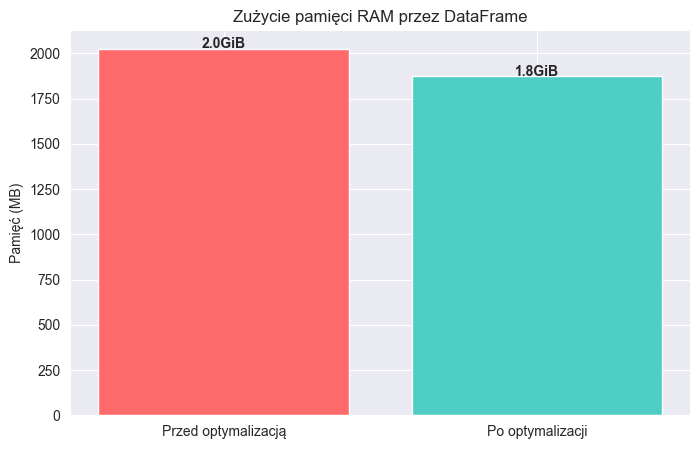

In [3]:
df_opt = df_oryginal.copy()

for kolumna in df_opt.columns:
    typ = str(df_opt[kolumna].dtype)

    if typ == 'object':
        df_opt[kolumna] = df_opt[kolumna].astype('category')
    elif 'int' in typ:
        df_opt[kolumna] = pd.to_numeric(df_opt[kolumna], downcast='integer')
    elif 'float' in typ:
        df_opt[kolumna] = pd.to_numeric(df_opt[kolumna], downcast='float')

ram_opt = sum(df_opt.memory_usage(deep=True))
print(f"Pamięć RAM (po optymalizacji): {sizeof_fmt(ram_opt)}")

plt.figure(figsize=(8, 5))
plt.bar(['Przed optymalizacją', 'Po optymalizacji'],
        [ram_oryginal / (1024**2), ram_opt / (1024**2)],
        color=['#FF6B6B', '#4ECDC4'])

plt.title('Zużycie pamięci RAM przez DataFrame')
plt.ylabel('Pamięć (MB)')
for i, v in enumerate([ram_oryginal, ram_opt]):
    plt.text(i, (v / (1024**2)) + 5, sizeof_fmt(v), ha='center', fontweight='bold')

plt.show()

In [4]:
def zmierz_czas(opis):
    def decorator(func):
        def wrapper(*args, **kwargs):
            start = datetime.now()
            wynik = func(*args, **kwargs)
            czas = datetime.now() - start
            print(f"[{opis}] Czas wykonania: {czas}")
            return wynik
        return wrapper
    return decorator

@zmierz_czas("Oryginał - Grupowanie i średnia")
def op1_oryg(): return df_oryginal.groupby('username')['likes'].mean()

@zmierz_czas("Zoptymalizowane - Grupowanie i średnia")
def op1_opt(): return df_opt.groupby('username')['likes'].mean()

@zmierz_czas("Oryginał - Filtrowanie (likes > 1000)")
def op2_oryg(): return df_oryginal[df_oryginal['likes'] > 1000]

@zmierz_czas("Zoptymalizowane - Filtrowanie (likes > 1000)")
def op2_opt(): return df_opt[df_opt['likes'] > 1000]

@zmierz_czas("Oryginał - Sortowanie po polubieniach")
def op3_oryg(): return df_oryginal.sort_values('likes')

@zmierz_czas("Zoptymalizowane - Sortowanie po polubieniach")
def op3_opt(): return df_opt.sort_values('likes')

print("--- Start testów wydajnościowych ---")
op1_oryg(); op1_opt()
print("-" * 30)
op2_oryg(); op2_opt()
print("-" * 30)
op3_oryg(); op3_opt()

--- Start testów wydajnościowych ---
[Oryginał - Grupowanie i średnia] Czas wykonania: 0:00:01.032313
[Zoptymalizowane - Grupowanie i średnia] Czas wykonania: 0:00:01.287532
------------------------------
[Oryginał - Filtrowanie (likes > 1000)] Czas wykonania: 0:00:01.521832
[Zoptymalizowane - Filtrowanie (likes > 1000)] Czas wykonania: 0:00:01.198418
------------------------------
[Oryginał - Sortowanie po polubieniach] Czas wykonania: 0:00:08.193936
[Zoptymalizowane - Sortowanie po polubieniach] Czas wykonania: 0:00:08.091035


,sid,sid_profile,post_id,profile_id,date,post_type,description,likes,comments,username,bio,following,followers,num_posts,is_business_account,lang,category
3180174,34851497,3630505,BwpbGtXD_qW,6996670125,2019-04-24 19:48:52,1,No description,0,0,k_o_mia,NaN,27,2,8,False,en,news_&_social_concern
1482730,31755464,4091901,BySp_wxBrMI,8005930128,2019-06-04 16:39:15,1,Have you booked yet?? Father’s Day Sunday 16th...,0,0,the_whitehart_uttoxeter,6-8 Carter Street Uttoxeter ST14 8EU Lounge-Br...,527,402,194,False,en,diaries_&_daily_life
2383214,35967674,3591830,ByiIySeBPvB,6938036520,2019-06-10 16:56:54,1,No description,0,0,obet_malaya,NaN,291,114,289,False,en,news_&_social_concern
309160,16834829,3531135,BTkkCuyDxgt,5405203525,2017-05-02 03:20:20,1,Year founded: 2010\nWhat they do: Gett is a gl...,0,0,israelistartupsnyc,NaN,6,19,14,False,en,business_&_entrepreneurs
4337750,39045442,3848957,BmD84aogIa1,5843816367,2018-08-04 17:18:56,1,‘Append to pass Appin,0,0,stephen_sayer,NaN,26,24,19,False,en,diaries_&_daily_life
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2410297,25415509,91738,Bv1vkqjgbNy,35306961,2019-04-04 18:07:13,1,will remember last night for the rest of my li...,2207053,13334,maisie_williams,@daisieapp,964,11637123,826,False,en,diaries_&_daily_life
3780765,38331091,3747199,BxLzya6FN6U,8443283,2019-05-08 04:18:44,1,Pinky's up • To the brilliant beast of @balmai...,2329077,7609,lizakoshy,God 1st.\nLittle brown girl with big dreams.\n...,1428,17920459,1782,True,en,celebrity_&_pop_culture
1227869,15396405,3513205,BwxEw9uHXIX,907025384,2019-04-27 19:07:35,1,When #IronMan Wears the same Tie as you!!\n#Wh...,2331497,16905,akshaykumar,#AkshayKumar,5,26252169,1173,False,en,film_tv_&_video
3780767,38331101,3747199,BwP4stXFS94,8443283,2019-04-14 21:47:13,1,liza koshella,2616479,10571,lizakoshy,God 1st.\nLittle brown girl with big dreams.\n...,1428,17920459,1782,True,en,diaries_&_daily_life


In [5]:
df_opt.to_csv('instagram_zoptymalizowane.csv', index=False)
print("Zapisano plik 'instagram_zoptymalizowane.csv'.")

Zapisano plik 'instagram_zoptymalizowane.csv'.


In [6]:
import pandas as pd
import os
import multiprocessing
from datetime import datetime

def sum_likes_chunk(filepath):
    df = pd.read_csv(filepath)
    return df['likes'].sum()

def main():
    plik_csv = 'instagram_zoptymalizowane.csv'
    rdzenie = multiprocessing.cpu_count()

    print(f"Wykryto rdzeni CPU: {rdzenie}")

    start = datetime.now()
    df_full = pd.read_csv(plik_csv)
    print(f"5.1 Czas (Całość na raz): {datetime.now() - start}")
        start = datetime.now()
    chunks = pd.read_csv(plik_csv, chunksize=100_000)
    df_chunks = pd.concat(chunks)
    print(f"5.2 Czas (Chunksize): {datetime.now() - start}")

    print("\nRozpoczynam podział pliku do Zadania 6...")
    from filesplit.split import Split
    katalog_podzialu = 'podzielone_csv'
    os.makedirs(katalog_podzialu, exist_ok=True)
    split = Split(plik_csv, katalog_podzialu)
    split.bylinecount(linecount=50_000, includeheader=True)

    pliki_podzielone = [os.path.join(katalog_podzialu, f) for f in os.listdir(katalog_podzialu) if f.endswith('.csv')]

    start = datetime.now()
    suma_sekwencyjna = sum([sum_likes_chunk(f) for f in pliki_podzielone])
    czas_sek = datetime.now() - start
    print(f"6. Czas liczenia sumy (Sekwencyjnie): {czas_sek} | Suma: {suma_sekwencyjna}")

    procesy = max(1, rdzenie - 2)
    start = datetime.now()
    with multiprocessing.Pool(processes=procesy) as pool:
        wyniki_multi = pool.map(sum_likes_chunk, pliki_podzielone)
        suma_multi = sum(wyniki_multi)
    czas_multi = datetime.now() - start
    print(f"6. Czas liczenia sumy (Multiprocessing - {procesy} procesów): {czas_multi} | Suma: {suma_multi}")

if __name__ == '__main__':
    main()

IndentationError: unexpected indent (1517433903.py, line 19)